<a href="https://colab.research.google.com/github/Anshul-ARK/nlp_lab_assignments/blob/main/nlp_lab222.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install automata-lib visual-automata
from automata.fa.dfa import DFA

from visual_automata.fa.dfa import VisualDFA

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.2/388.2 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 9.3 MB/s eta 0:00:00
  Created wheel for colormath: filename=colormath-3.0.0-py3-none-any.whl size=39405 sha256=263c11717c312a70ac21d168a8b294484dae6

[Rejected]                         
Step: Current state: Input symbol: New state:
1                →q0             d        *q1
2                *q1             o        *q1
3                *q1             g        *q1
4                *q1             c        *q1
5                *q1             a        *q1
6                *q1             t        *q1
7                *q1             S         q2

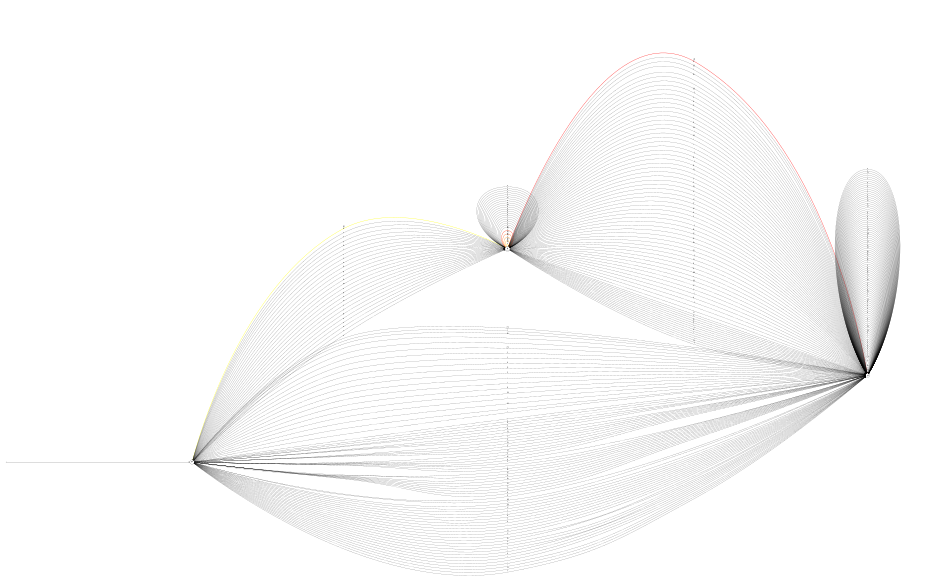

In [ ]:
import string
lowercase=set(string.ascii_lowercase)
all_chars = set(string.printable)
dfa=VisualDFA(
    states={'q0','q1','q2'},
    input_symbols=all_chars,
    transitions={
        'q0':{ch: ('q1' if ch in lowercase else 'q2') for ch in all_chars},
        'q1':{ch: ('q1' if ch in lowercase else 'q2') for ch in all_chars},
        'q2':{ch: 'q2' for ch in all_chars},
    },
    initial_state='q0',
    final_states={'q1'}
)

graph = dfa.show_diagram("dogcatS")
graph.attr(rankdir="LR")
graph.attr(size="12,6!")
graph.attr(ratio="fill")
from IPython.display import Image
Image(graph.pipe(format='png'))


In [ ]:
!apt-get install -y graphviz graphviz-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 35 not upgraded.
Need to get 2,434 kB of archives.
After this operation, 7,681 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2.1 [2,038 kB]
Get:3 http://a

In [ ]:
import re

with open("brown_nouns.txt", "r") as f:
    nouns = [line.strip() for line in f if line.strip()]

def pluralize_fst(word):
    vowels = "aeiou"
    if re.search(r'(s|z|x|ch|sh)$', word):
        return f"{word}+N+SG", f"{word}es+N+PL"
    elif re.search(r'[^aeiou]y$', word):
        return f"{word}+N+SG", f"{word[:-1]}ies+N+PL"

    elif re.search(r'^[a-z]+$', word):
        return f"{word}+N+SG", f"{word}s+N+PL"
    else:
        return "Invalid Word", None

results = []
for w in nouns:
    sg, pl = pluralize_fst(w)
    if sg == "Invalid Word":
        results.append(f"{w} = Invalid Word")
    else:
        results.append(f"{w} = {sg}")
        results.append(f"{pl.split('+')[0]} = {pl}")

with open("noun_fst_output.txt", "w") as f:
    for line in results:
        f.write(line + "\n")

print("Processing complete. Output saved to noun_fst_output.txt")


Processing complete. Output saved to noun_fst_output.txt


[Accepted]                         
Step: Current state: Input symbol: New state:
1                →q0             f         q1
2                 q1             o         q1
3                 q1             x         qE
4                 qE             #        *qF

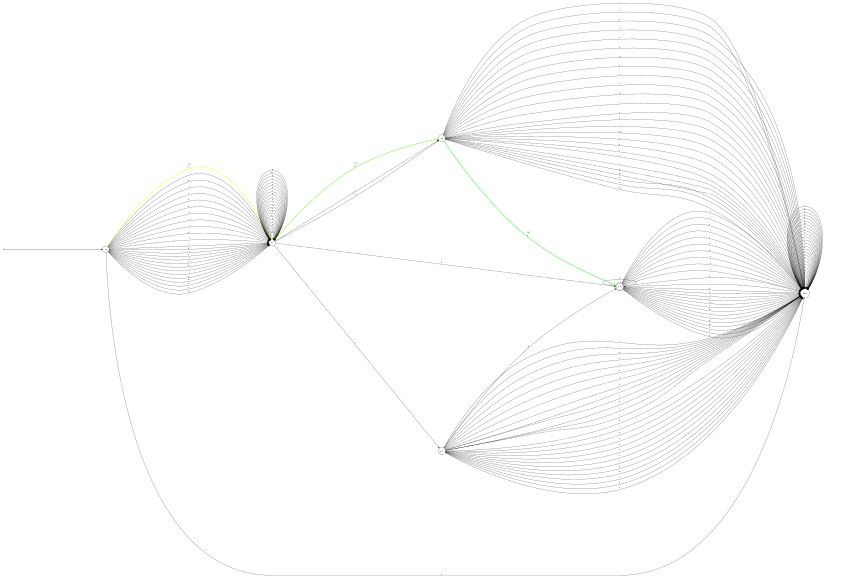

In [ ]:
from IPython.display import Image

letters = set("abcdefghijklmnopqrstuvwxyz")
special_endings = {"s", "z", "x"}
special_two = {"ch", "sh"}
vowels = set("aeiou")

transitions = {
    'q0': {},
    'q1': {},
    'qE': {},
    'qY': {},
    'qF': {},
    'qErr': {}
}

for ch in letters:
    transitions['q0'][ch] = 'q1'
transitions['q0']['#'] = 'qF'
transitions['q0']['#'] = 'qErr'

for ch in letters:
    if ch in special_endings:
        transitions['q1'][ch] = 'qE'
    elif ch == 'y':
        transitions['q1'][ch] = 'qY'
    else:
        transitions['q1'][ch] = 'q1'
transitions['q1']['#'] = 'qF'


end_marker = '#'
transitions['qE'][end_marker] = 'qF'
transitions['qY'][end_marker] = 'qF'

for symbol in letters:
    transitions['qE'][symbol] = 'qErr'
    transitions['qY'][symbol] = 'qErr'

transitions['qF'][end_marker] = 'qF'
for symbol in letters:
    transitions['qF'][symbol] = 'qErr'

for symbol in letters | {end_marker}:
    transitions['qErr'][symbol] = 'qErr'

dfa = VisualDFA(
    states={'q0', 'q1', 'qE', 'qY', 'qF', 'qErr'},
    input_symbols=letters | {end_marker},
    transitions=transitions,
    initial_state='q0',
    final_states={'qF'}
)

graph = dfa.show_diagram("fox#")
graph.attr(rankdir="LR")
graph.attr(size="15,6!")
graph.attr(ratio="fill")
Image(graph.pipe(format='png'))